In [2]:
#%load_ext autoreload
#%autoreload 2

In [3]:
import torch
import os
import sys
from GCN import GCN
from GraphSAGE import GraphSAGE
from GAT import GAT


# Import the custom dataset
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if parent_dir not in sys.path:
    sys.path.append(parent_dir)
from Datasets.garesearch_dataset import GAResearchDataset

from torch_geometric.datasets import HeterophilousGraphDataset
from torch_geometric.loader import DataLoader
import numpy as np
import random
import time
from sklearn.metrics import f1_score, accuracy_score

def seed_torch(seed=0):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # if you are using multi-GPU
    #add to warn
    #torch.use_deterministic_algorithms(True, warn_only=True) 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_torch(seed=42)


In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [5]:
## Instantiate the ExperimentTracker
from results_manager import ExperimentTracker

tracker = ExperimentTracker(dataset_name="Roman Empire", node_feature_type="Custom BERT - Trained on Roman Empire")

In [6]:
args = {
      'device': device,
      'num_layers': 3,
      'hidden_dim': 256,
      'dropout': 0.3,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 0,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 0
  }

# Setup

In [7]:
#dataset = HeterophilousGraphDataset(root ='tmp/Amazon-ratings', name='Amazon-ratings')
dataset = GAResearchDataset(root ='tmp/roman-custom-transformer', name='roman-custom-transformer')

In [8]:
num_features = dataset.num_features
num_classes = dataset.num_classes
num_nodes = dataset[0].num_nodes
num_edges = dataset[0].num_edges

print(f"Number of graphs in dataset: {len(dataset)}")
print(f"Number of features for each node: {num_features}")
print(f"Number of num_classes : {num_classes}")

print(f"Number of num_nodes : {num_nodes}")
print(f"Number of num_edges : {num_edges}")

Number of graphs in dataset: 1
Number of features for each node: 256
Number of num_classes : 18
Number of num_nodes : 22600
Number of num_edges : 65368


In [9]:
# Number of splits available
print(dataset[0].train_mask.shape)
print(dataset[0].test_mask.shape)
print(dataset[0].val_mask.shape)

torch.Size([22600, 10])
torch.Size([22600, 10])
torch.Size([22600, 10])


In [10]:
print(dataset[0].train_mask[:,args['split_idx']])
print(dataset[0].train_mask[:,args['split_idx']].shape)

tensor([ True,  True,  True,  ...,  True,  True, False])
torch.Size([22600])


In [11]:
def train(model, data, optimizer, criterion):
    """
    one training epoch
    model -  GNN (GCNConv or GraphSAGE)
    data - Entire Graph Dataset i.e. dataset[0]
    optimizer - algorithm that updates model weights (Adam, SGD, etc.)
    criterion - loss function (often BCEWithLogitsLoss for the PPI dataset)
    """
    #Training mode
    model.train()
    #TODO: Move the data to device outside the training loop
    #data = data.to(device)
    optimizer.zero_grad()
    out = model(data.x, data.edge_index)
    split_idx = args['split_idx']
    loss = criterion(out[data.train_mask[:,split_idx]], data.y[data.train_mask[:,split_idx]])
    loss.backward()
    optimizer.step()
    
    return loss.item()

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def test(model, data, mask, return_preds=False):
    """
    data: dataset[0] - 1 entire graph composed of all labeled train, test, val
    mask: array of [True, False, ....]
    """
    #switch to evaluation mode
    model.eval()
    # ys: Ground Truth Labels, preds: model predictions across all batches
    ys, preds = [], []

    with torch.no_grad():
        out = model(data.x, data.edge_index)
        pred = out[mask].argmax(dim=1).cpu().numpy()
        y = data.y[mask].cpu().numpy()
    
    #macro - how model handles small classes
    f1 = f1_score(y, pred, average='macro', zero_division=0)
    #f1 = f1_score(y, pred, average='micro', zero_division=0)
    acc = accuracy_score(y, pred)

    if return_preds:
        return f1, acc, y, pred
    return f1, acc
        

In [13]:
def train_and_evaluate(model, data, optimizer, scheduler, criterion, model_name, epochs=100):
    best_val_f1 = 0
    train_losses, val_f1s, val_accs, test_f1s, test_accs = [],[],[],[],[]
    training_time = 0

    for epoch in range(1, epochs+1):
        start_time = time.time()

        loss = train(model, data, optimizer, criterion)
        
        if scheduler:
            scheduler.step()

        epoch_time = time.time() - start_time
        training_time += epoch_time

        split_idx = args['split_idx']
        val_f1, val_acc = test(model, data, data.val_mask[:,split_idx])
        test_f1, test_acc = test(model, data, data.test_mask[:,split_idx])

        train_losses.append(loss)
        val_f1s.append(val_f1)
        test_f1s.append(test_f1)
        val_accs.append(val_acc)
        test_accs.append(test_acc)

        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            torch.save(model.state_dict(), 'best_model_gcn.pth')

        tracker.log_epoch(model_name=model_name, epoch=epoch, loss=loss, val_f1=val_f1, val_acc=val_acc)
        if epoch % 10 == 0:
            print(f"Epoch: {epoch:03d}, "
                f"Loss: {loss:.4f}, "
                f"Val F1: {val_f1:.4f},"
                f"Val Acc: {val_acc:.4f}, "
                f"Time: {epoch_time:.2f}s"
                )


    model.load_state_dict(torch.load('best_model_gcn.pth', map_location=device))
    test_f1, test_acc, y_true, y_pred = test(model, data, data.test_mask[:,split_idx], return_preds=True)
    print(f"Test F1: {test_f1:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")

    cm = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize

    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', 
                xticklabels=range(18), yticklabels=range(18))
    plt.title('Normalized Confusion Matrix: Roman Empire Syntactic Roles')
    plt.xlabel('Predicted Class')
    plt.ylabel('True Class')
    plt.show()

    tracker.save_results(
        model_name=model_name, 
        test_f1=test_f1, 
        test_acc=test_acc,
        params=args # Assuming 'args' contains your hyperparams
    )
    return model, train_losses, val_f1s, test_f1s, training_time

In [14]:
def build_optimizer(args, params):
    
    filter_fn = filter(lambda p : p.requires_grad, params)
    weight_decay = args['weight_decay']
    if args['opt'] == 'adam':
        optimizer = torch.optim.Adam(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'sgd':
        optimizer = torch.optim.SGD(filter_fn, lr=args['lr'], momentum=0.95, weight_decay=weight_decay)
    elif args['opt'] == 'rmsprop':
        optimizer = torch.optim.RMSprop(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    elif args['opt'] == 'adagrad':
        optimizer = torch.optim.Adagrad(filter_fn, lr=args['lr'], weight_decay=weight_decay)
    if args['opt_scheduler'] == 'none':
        return None, optimizer
    elif args['opt_scheduler'] == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=args['opt_decay_step'], gamma=args['opt_decay_rate'])
    elif args['opt_scheduler'] == 'cos':
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=args['opt_restart'])
    return scheduler, optimizer

In [15]:
import matplotlib.pyplot as plt
def plot_results(results, title, label, ylabel):
    plt.figure(figsize=(3,2))
    epochs = range(1, len(results)+1)
    plt.plot(epochs, results, label = label)
    plt.title(title)
    plt.xlabel('Epochs')
    plt.ylabel(ylabel)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.legend()
    plt.show()

In [16]:
def gcn_run():
    model = GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


# GCN

Training GCN
Epoch: 010, Loss: 2.0901, Val F1: 0.1345,Val Acc: 0.1942, Time: 0.01s
Epoch: 020, Loss: 1.8921, Val F1: 0.1639,Val Acc: 0.1907, Time: 0.01s
Epoch: 030, Loss: 1.7355, Val F1: 0.1739,Val Acc: 0.2150, Time: 0.01s
Epoch: 040, Loss: 1.5794, Val F1: 0.1814,Val Acc: 0.2246, Time: 0.01s
Epoch: 050, Loss: 1.4201, Val F1: 0.1573,Val Acc: 0.2069, Time: 0.01s
Epoch: 060, Loss: 1.2846, Val F1: 0.1429,Val Acc: 0.1739, Time: 0.01s
Epoch: 070, Loss: 1.1922, Val F1: 0.1212,Val Acc: 0.1595, Time: 0.01s
Epoch: 080, Loss: 1.0940, Val F1: 0.1331,Val Acc: 0.1551, Time: 0.01s
Epoch: 090, Loss: 1.0252, Val F1: 0.1301,Val Acc: 0.1522, Time: 0.01s
Epoch: 100, Loss: 0.9662, Val F1: 0.1158,Val Acc: 0.1392, Time: 0.01s
Test F1: 0.1898
Test Accuracy: 0.2363


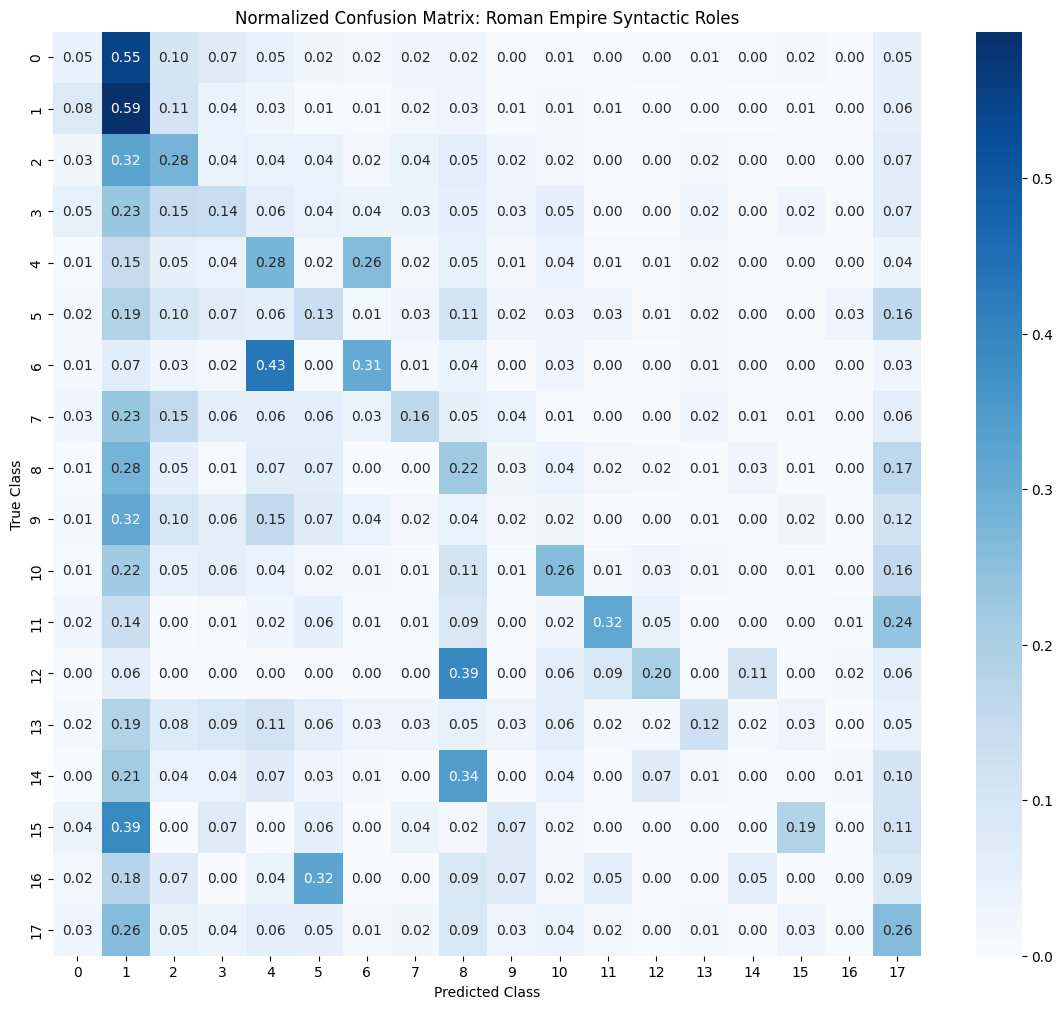

GCN results saved using Custom BERT - Trained on Roman Empire features.
Training Time 10.972338199615479


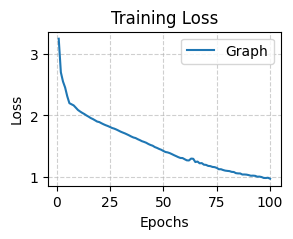

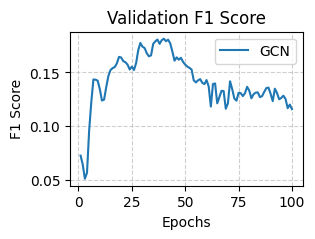

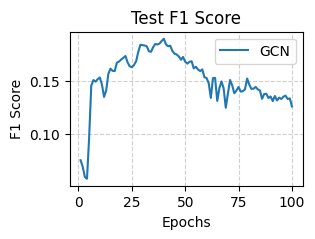

In [17]:
gcn_run()

In [18]:
def graphSage_run():
    model = GraphSAGE(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training Graph SAGE")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data,
        optimizer,
        scheduler, 
        criterion, 
        model_name="GraphSAGE",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GraphSAGE','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GraphSAGE','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GraphSAGE','F1 Score')


Training Graph SAGE
Epoch: 010, Loss: 1.5299, Val F1: 0.3037,Val Acc: 0.4896, Time: 0.00s
Epoch: 020, Loss: 1.2019, Val F1: 0.4445,Val Acc: 0.5637, Time: 0.00s
Epoch: 030, Loss: 0.9467, Val F1: 0.4792,Val Acc: 0.5951, Time: 0.00s
Epoch: 040, Loss: 0.7071, Val F1: 0.5356,Val Acc: 0.6254, Time: 0.00s
Epoch: 050, Loss: 0.4823, Val F1: 0.5680,Val Acc: 0.6343, Time: 0.00s
Epoch: 060, Loss: 0.3099, Val F1: 0.5586,Val Acc: 0.6223, Time: 0.00s
Epoch: 070, Loss: 0.2008, Val F1: 0.5678,Val Acc: 0.6310, Time: 0.00s
Epoch: 080, Loss: 0.1441, Val F1: 0.5615,Val Acc: 0.6336, Time: 0.00s
Epoch: 090, Loss: 0.1079, Val F1: 0.5643,Val Acc: 0.6367, Time: 0.00s
Epoch: 100, Loss: 0.0820, Val F1: 0.5703,Val Acc: 0.6438, Time: 0.00s
Test F1: 0.5510
Test Accuracy: 0.6210


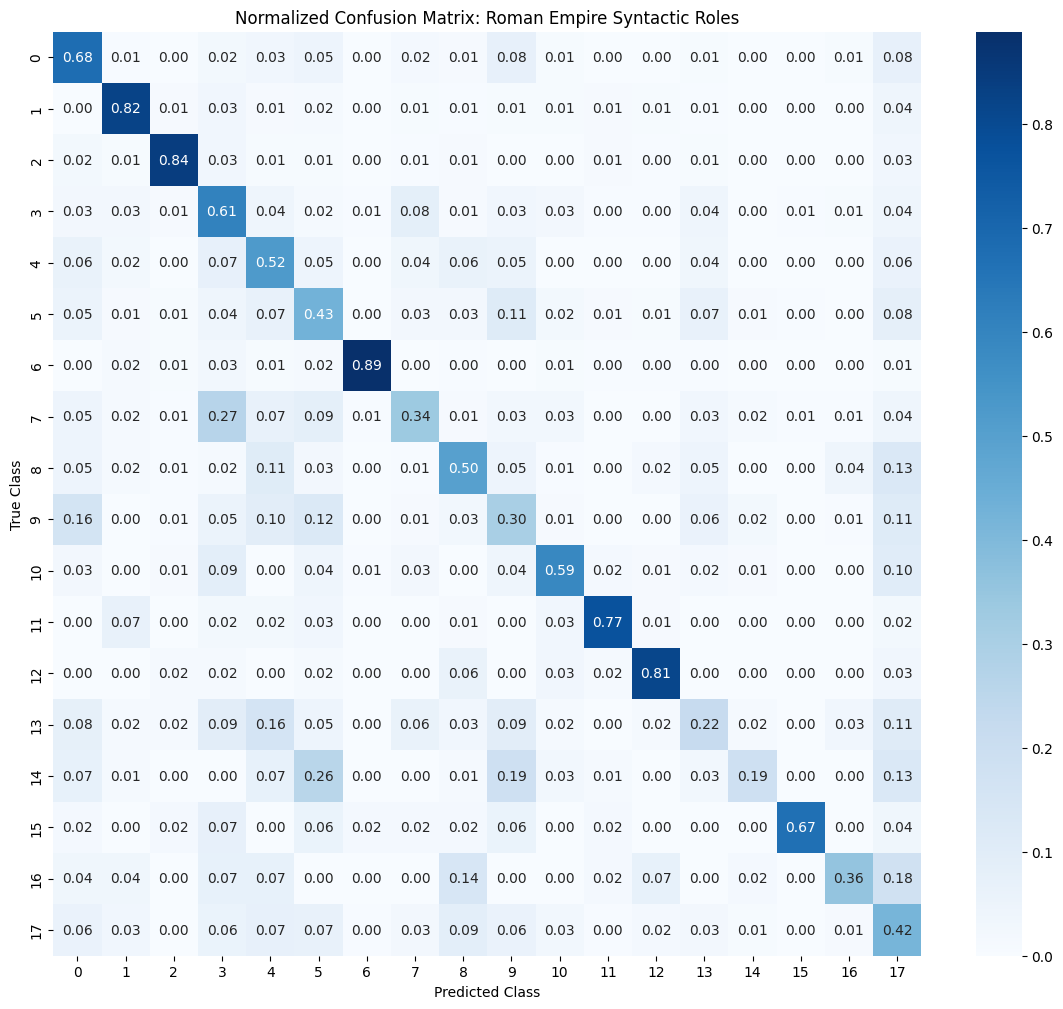

GRAPHSAGE results saved using Custom BERT - Trained on Roman Empire features.
Training Time 0.8068783283233643


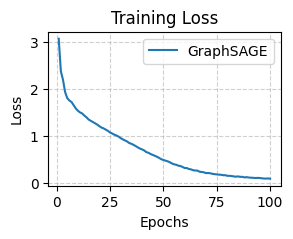

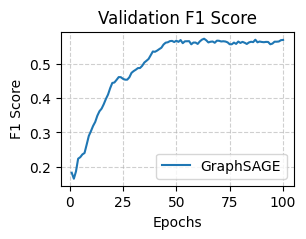

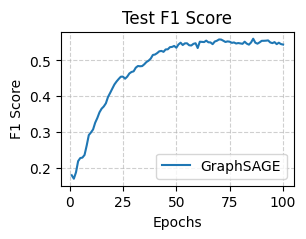

In [19]:
graphSage_run()

In [20]:
def gat_run():
    model = GAT(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'],
                heads=args['heads'],
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    data = dataset[0].to(device)
    print("Training GAT")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GAT",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'GAT','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GAT','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GAT','F1 Score')


Training GAT
Epoch: 010, Loss: 2.7909, Val F1: 0.0672,Val Acc: 0.1622, Time: 0.02s
Epoch: 020, Loss: 2.5560, Val F1: 0.1059,Val Acc: 0.1883, Time: 0.02s
Epoch: 030, Loss: 2.4782, Val F1: 0.1123,Val Acc: 0.2150, Time: 0.02s
Epoch: 040, Loss: 2.3964, Val F1: 0.1246,Val Acc: 0.2195, Time: 0.02s
Epoch: 050, Loss: 2.3244, Val F1: 0.1409,Val Acc: 0.2332, Time: 0.02s
Epoch: 060, Loss: 2.2466, Val F1: 0.1729,Val Acc: 0.2451, Time: 0.02s
Epoch: 070, Loss: 2.2026, Val F1: 0.1750,Val Acc: 0.2445, Time: 0.02s
Epoch: 080, Loss: 2.1498, Val F1: 0.1801,Val Acc: 0.2458, Time: 0.02s
Epoch: 090, Loss: 2.0944, Val F1: 0.1801,Val Acc: 0.2487, Time: 0.02s
Epoch: 100, Loss: 2.0499, Val F1: 0.1802,Val Acc: 0.2473, Time: 0.02s
Test F1: 0.1964
Test Accuracy: 0.2675


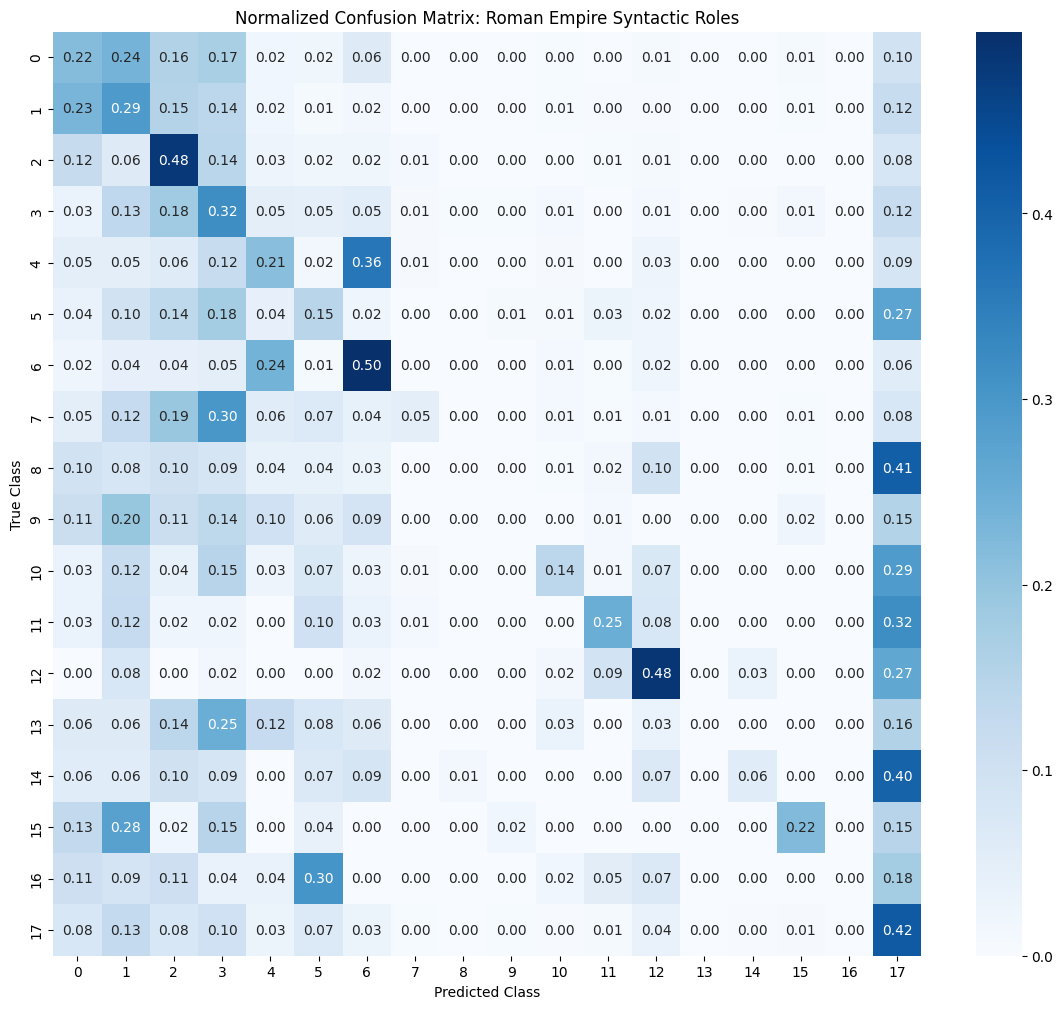

GAT results saved using Custom BERT - Trained on Roman Empire features.
Training Time 2.7064895629882812


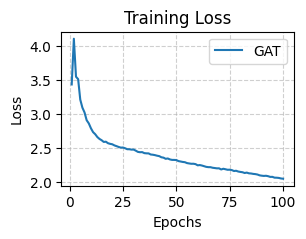

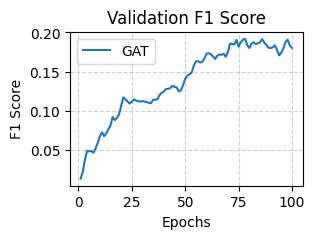

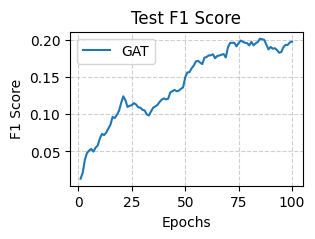

In [21]:
gat_run()

# GCN2Conv

In [22]:
from GCN2 import GCN2

In [23]:
args = {
      'device': device,
      'num_layers': 30,
      'hidden_dim': 256,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 400,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [24]:
def gcn2_run():
    model = GCN2(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, num_layers=args['num_layers'], 
                dropout=args['dropout'], alpha=args['alpha'], theta=args['theta']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="GCN2",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'GCN','F1 Score')


Training GCN
Epoch: 010, Loss: 2.3671, Val F1: 0.1121,Val Acc: 0.2571, Time: 0.07s
Epoch: 020, Loss: 2.1512, Val F1: 0.1642,Val Acc: 0.3250, Time: 0.07s
Epoch: 030, Loss: 1.9490, Val F1: 0.2557,Val Acc: 0.4206, Time: 0.07s
Epoch: 040, Loss: 1.7541, Val F1: 0.3283,Val Acc: 0.4706, Time: 0.07s
Epoch: 050, Loss: 1.5687, Val F1: 0.3850,Val Acc: 0.5042, Time: 0.07s
Epoch: 060, Loss: 1.3937, Val F1: 0.4167,Val Acc: 0.5321, Time: 0.07s
Epoch: 070, Loss: 1.2438, Val F1: 0.4382,Val Acc: 0.5376, Time: 0.07s
Epoch: 080, Loss: 1.0872, Val F1: 0.4330,Val Acc: 0.5221, Time: 0.07s
Epoch: 090, Loss: 0.9041, Val F1: 0.4252,Val Acc: 0.5133, Time: 0.07s
Epoch: 100, Loss: 0.7311, Val F1: 0.4025,Val Acc: 0.4816, Time: 0.07s
Epoch: 110, Loss: 0.5834, Val F1: 0.3888,Val Acc: 0.4746, Time: 0.07s
Epoch: 120, Loss: 0.4968, Val F1: 0.4082,Val Acc: 0.4856, Time: 0.07s
Epoch: 130, Loss: 0.4515, Val F1: 0.4344,Val Acc: 0.5285, Time: 0.07s
Epoch: 140, Loss: 0.4098, Val F1: 0.4336,Val Acc: 0.5228, Time: 0.07s
Epoch: 

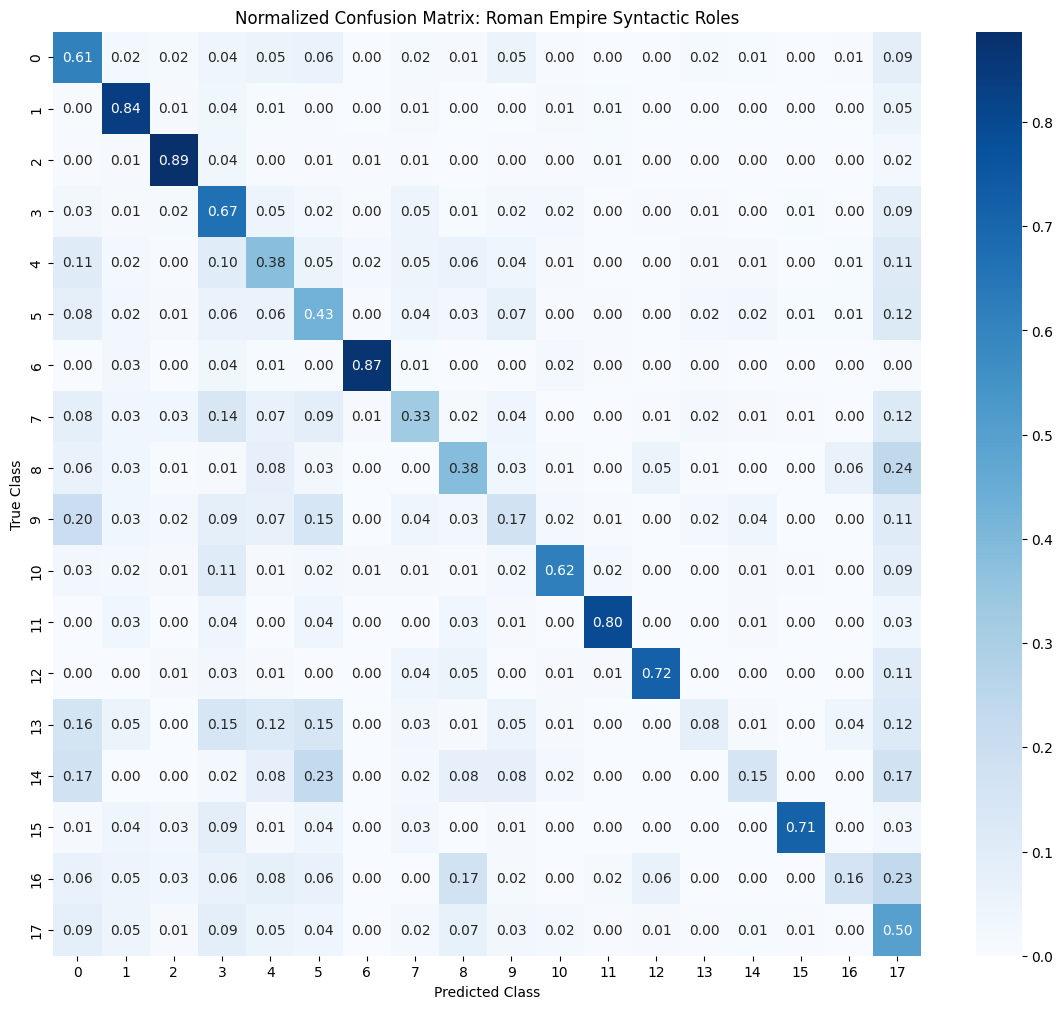

GCN2 results saved using Custom BERT - Trained on Roman Empire features.
Training Time 28.48947787284851


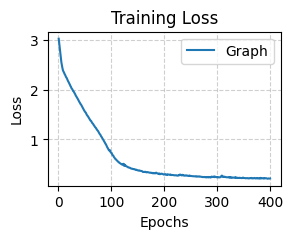

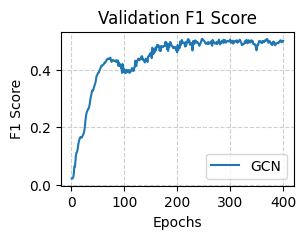

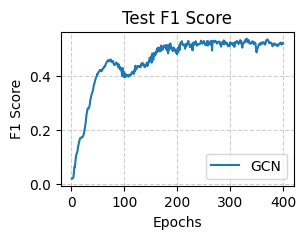

In [25]:
gcn2_run()

# H2GCN

In [46]:
from H2GCN import H2GCN

In [24]:
args = {
      'device': device,
      'num_layers': 30, #Not applicable to H2GCN
      'hidden_dim': 300,
      'dropout': 0.5,
      'lr': 0.01,
      'epochs': 100,
      'opt': 'adam',
      'opt_scheduler': 'none',
      'weight_decay': 5e-4,
      'opt_decay_step': 1,
      'opt_decay_rate':0,
      'opt_restart':0,
      'training_batch_size': 1,
      'test_batch_size': 1,
      'val_batch_size': 1,
      'alpha': 0.1,
      'theta':0.5,
      #heads for GAT
      'heads': 2,
      #heterophilous split of the training / val / test
      'split_idx': 1
  }

In [ ]:
def h2GCN_run():
    model = H2GCN(in_channels=num_features, hidden_channels=args['hidden_dim'], 
                out_channels=num_classes, 
                dropout=args['dropout']).to(device)
    criterion = torch.nn.CrossEntropyLoss()
    scheduler, optimizer = build_optimizer(args, model.parameters())
    
    data = dataset[0].to(device)

    print("Training H2GCN")
    trained_model, train_losses, val_f1s, test_f1s, training_time  = train_and_evaluate(
        model, 
        data, 
        optimizer,
        scheduler, 
        criterion, 
        model_name="H2GCN",
        epochs=args["epochs"])
    print("Training Time", training_time)

    plot_results(train_losses, 'Training Loss', 'Graph','Loss')

    plot_results(val_f1s, 'Validation F1 Score', 'H2GCN','F1 Score')

    plot_results(test_f1s, 'Test F1 Score', 'H2GCN','F1 Score')


Training H2GCN
Epoch: 010, Loss: 1.6240, Val F1: 0.2084,Val Acc: 0.3128, Time: 0.01s
Epoch: 020, Loss: 1.2398, Val F1: 0.3777,Val Acc: 0.5046, Time: 0.01s
Epoch: 030, Loss: 1.0478, Val F1: 0.4782,Val Acc: 0.5825, Time: 0.01s
Epoch: 040, Loss: 0.8933, Val F1: 0.4438,Val Acc: 0.5591, Time: 0.01s
Epoch: 050, Loss: 0.7689, Val F1: 0.3871,Val Acc: 0.4768, Time: 0.01s
Epoch: 060, Loss: 0.6808, Val F1: 0.4158,Val Acc: 0.5126, Time: 0.01s
Epoch: 070, Loss: 0.6099, Val F1: 0.4502,Val Acc: 0.5454, Time: 0.01s
Epoch: 080, Loss: 0.5302, Val F1: 0.4975,Val Acc: 0.5931, Time: 0.01s
Epoch: 090, Loss: 0.4866, Val F1: 0.5008,Val Acc: 0.5799, Time: 0.01s
Epoch: 100, Loss: 0.4548, Val F1: 0.4963,Val Acc: 0.5960, Time: 0.01s
Epoch: 110, Loss: 0.4449, Val F1: 0.5072,Val Acc: 0.5549, Time: 0.01s
Epoch: 120, Loss: 0.4061, Val F1: 0.5049,Val Acc: 0.5803, Time: 0.01s
Epoch: 130, Loss: 0.3737, Val F1: 0.4997,Val Acc: 0.5845, Time: 0.01s
Epoch: 140, Loss: 0.3668, Val F1: 0.5113,Val Acc: 0.5850, Time: 0.01s
Epoch

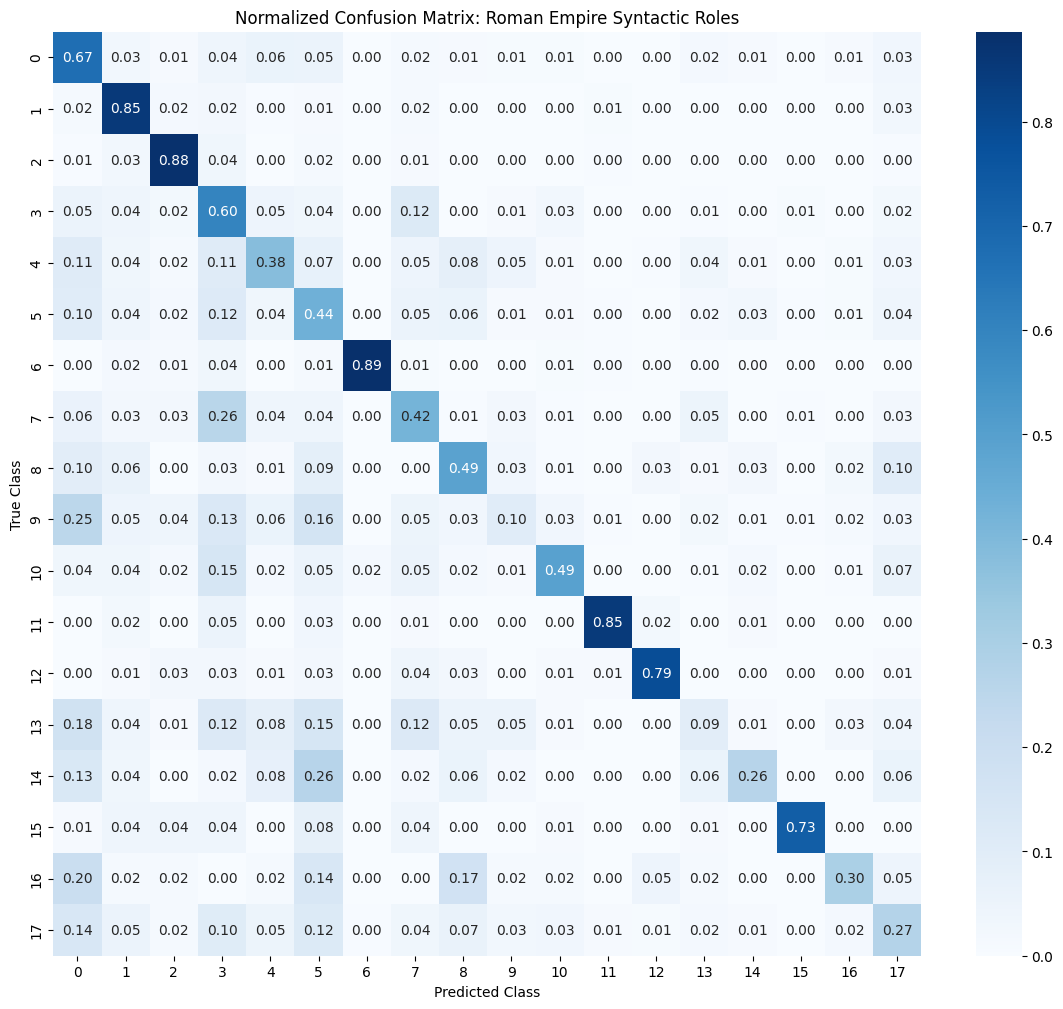

Training Time 3.296255350112915


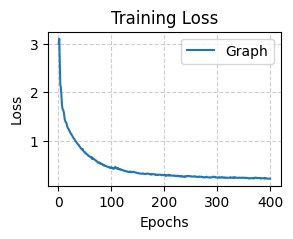

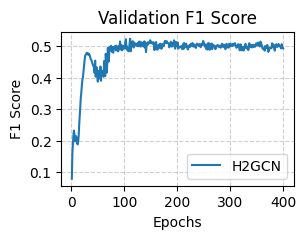

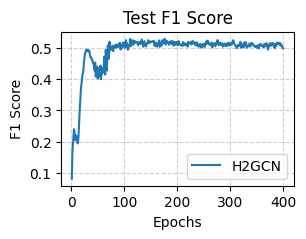

In [47]:
h2GCN_run()